# Sobre

### Nosso objetivo é criar um modelo de Machine Learning Simples utilizando Scikit-Learning que tenta “adivinhar” a nota dos candidatos em matemática (NU_NOTA_MT).


- Como variável de entrada, utilizaremos as colunas do questionário sócio econômico, acrescridas de cor/raça, tipo de escola, estado da prova e estado civil. Ou seja, utilize as colunas:  
NU_ANO, Q001, Q002, Q003, Q004, Q005, Q006, Q007, Q008, Q009, Q010, Q011, Q012, Q013, Q014, Q015, Q016, Q017, Q018, Q019, Q020, Q021, Q022, Q023, Q024, Q025, Q026, Q027, TP_ESTADO_CIVIL, TP_COR_RACA, TP_ESCOLA, CO_UF_PROVA.

- Random Forest só irá aceitar entradas numéricas.
  - Como existem colunas textuais, precisamos transformá-las em categóricas numéricas *
- Devido diferença de colunas, vamos usar o ano como uma coluna de entrada *
- Considere apenas alunos que fizeram a prova de matemática (TP_PRESENCA_MT=1)  

- Missing Values (alternativas?):
  - Caso o campo não esteja preenchido, preencher com zero.
  - Alternativa: Como temos uma grande quantidade de dados, podemos considerar apenas os alunos que possuem todos os campos necessários preenchidos (Not Null)

- Treino e Teste (devem ser determinísticos)
  - Colocar 80% dos dados em uma tabela chamada enem.ml_treino em teu dataset
  - Colocar 20% dos dados em uma tabela chamada enem. ml_teste em teu dataset

---
Pesquisar comandos úteis como:  
CASE .. WHEN .. END, MOD, CONCAT, ML.LABEL_ENCODER,
RAND, farm_fingerprint, GENERATE_UUID


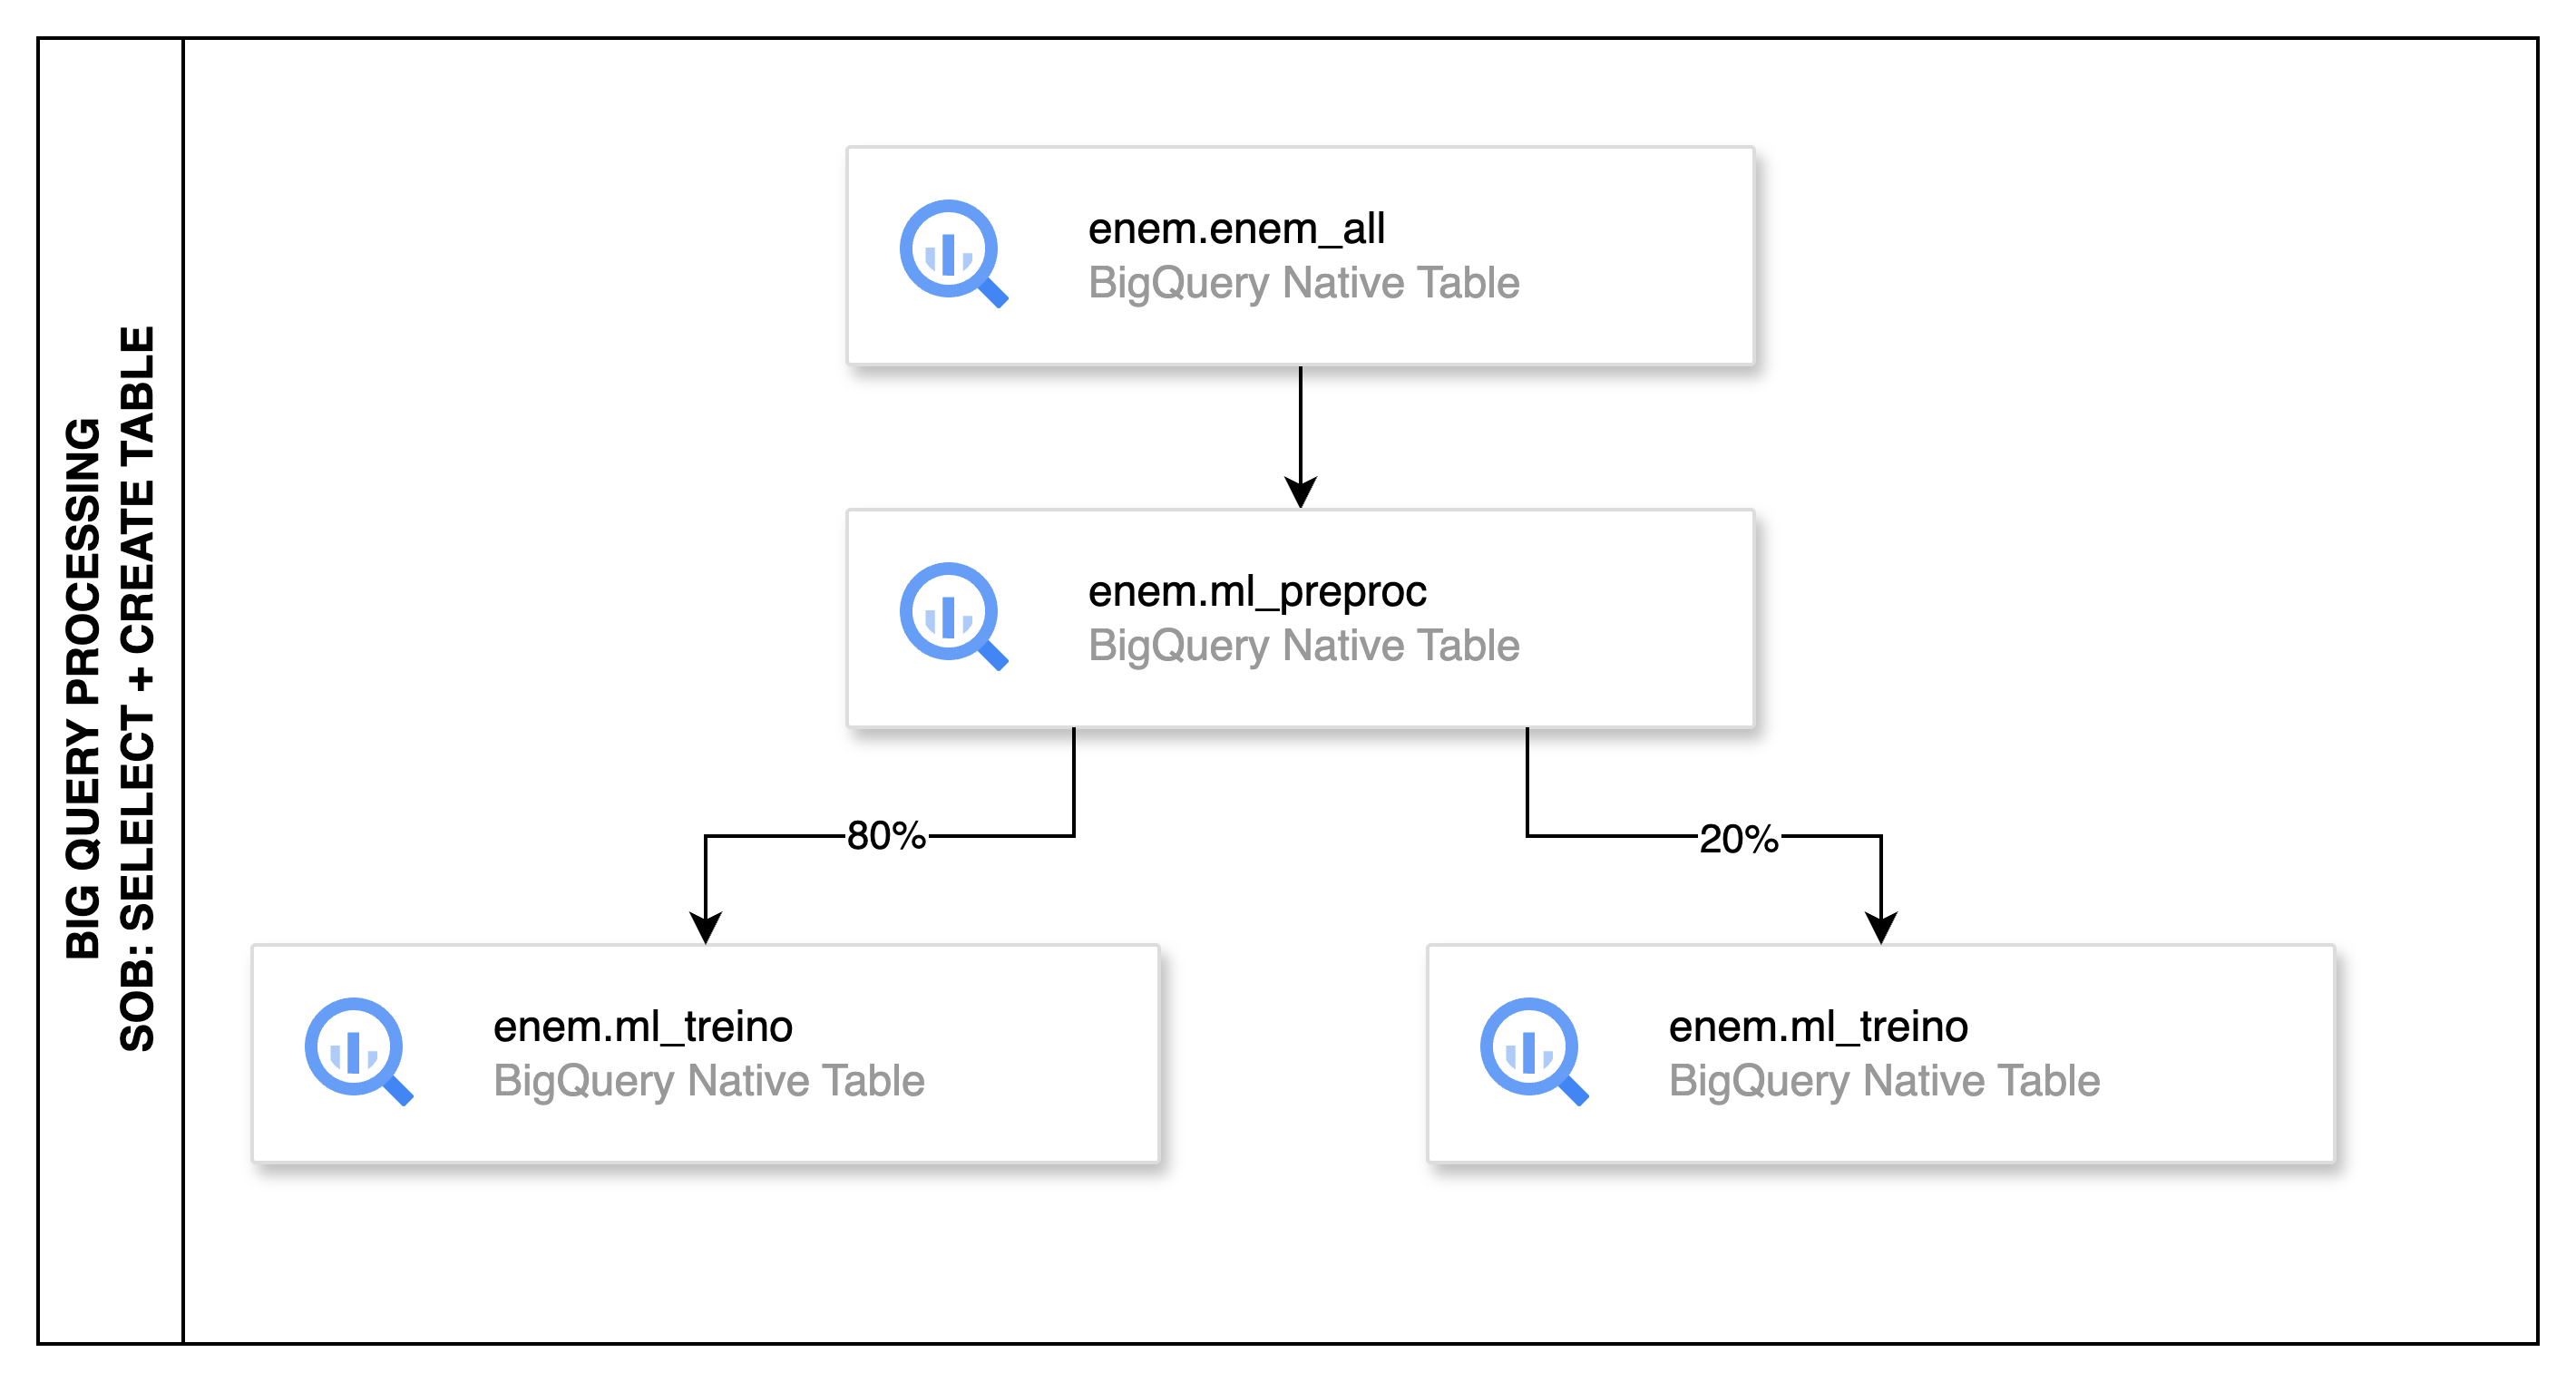

# Bibliotecas

In [2]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import urllib.request
from google.cloud import bigquery
from google.oauth2 import service_account


# Autenticação do Colab com o Bigquery

In [3]:
from google.colab import auth
auth.authenticate_user()

In [4]:
#@title Preenchimento do código do projeto
#@markdown Preencha abaixo o código do teu projeto na GCP. <br/>
#@markdown Após preenchimento do código, execute essa célula.   <br/>

project_id = "fiap10dtsr-459723"  #@param {type: "string"}
#@markdown ---
clientbq = bigquery.Client(project=project_id)


A célula a seguir testa a conexão do Big Query, listando todos os datasets disponíveis.

In [5]:
for dataset in clientbq.list_datasets():
  print(dataset.dataset_id)

enem


# Geração de Tabela com Feature Engineering





## Dados de Treinamento Pré Processados


Use a célula a seguir para colocar os seus comandos de pré-processamento

In [28]:
%%time
query_sql = f"""
CREATE OR REPLACE TABLE enem.enem_preproc AS SELECT
  ROW_NUMBER() OVER() as ID,
  NU_NOTA_MT,
  NU_ANO,
  ML.LABEL_ENCODER(Q001) OVER() as Q001,
  ML.LABEL_ENCODER(Q002) OVER() as Q002,
  ML.LABEL_ENCODER(Q003) OVER() as Q003,
  ML.LABEL_ENCODER(Q004) OVER() as Q004,
  CASE WHEN Q005 IS NULL THEN 0 ELSE Q005 END AS Q005,
  ML.LABEL_ENCODER(Q006) OVER() as Q006,
  ML.LABEL_ENCODER(Q007) OVER() as Q007,
  ML.LABEL_ENCODER(Q008) OVER() as Q008,
  ML.LABEL_ENCODER(Q009) OVER() as Q009,
  ML.LABEL_ENCODER(Q010) OVER() as Q010,
  ML.LABEL_ENCODER(Q011) OVER() as Q011,
  ML.LABEL_ENCODER(Q012) OVER() as Q012,
  ML.LABEL_ENCODER(Q013) OVER() as Q013,
  ML.LABEL_ENCODER(Q014) OVER() as Q014,
  ML.LABEL_ENCODER(Q015) OVER() as Q015,
  ML.LABEL_ENCODER(Q016) OVER() as Q016,
  ML.LABEL_ENCODER(Q017) OVER() as Q017,
  ML.LABEL_ENCODER(Q018) OVER() as Q018,
  ML.LABEL_ENCODER(Q019) OVER() as Q019,
  ML.LABEL_ENCODER(Q020) OVER() as Q020,
  ML.LABEL_ENCODER(Q021) OVER() as Q021,
  ML.LABEL_ENCODER(Q022) OVER() as Q022,
  ML.LABEL_ENCODER(Q023) OVER() as Q023,
  ML.LABEL_ENCODER(Q024) OVER() as Q024,
  ML.LABEL_ENCODER(Q025) OVER() as Q025,
  ML.LABEL_ENCODER(Q026) OVER() as Q026,
  ML.LABEL_ENCODER(Q027) OVER() as Q027,
  CASE WHEN TP_ESTADO_CIVIL IS NULL THEN 0 ELSE TP_ESTADO_CIVIL END AS TP_ESTADO_CIVIL,
  CASE WHEN TP_COR_RACA IS NULL THEN 0 ELSE TP_COR_RACA END AS TP_COR_RACA,
  CASE WHEN TP_ESCOLA IS NULL THEN 0 ELSE TP_ESCOLA END AS TP_ESCOLA,
  CASE WHEN CO_UF_PROVA  IS NULL THEN 0 ELSE CO_UF_PROVA END AS CO_UF_PROVA,
  MOD(ABS(FARM_FINGERPRINT(CAST(ROW_NUMBER() OVER() AS STRING) || '42')), 100) AS rand_bucket
  FROM `{project_id}.enem.enem_all`
  WHERE
  TP_PRESENCA_MT=1
  AND NU_NOTA_MT IS NOT NULL
"""
query_job = clientbq.query(query_sql)  # Make an API request.
query_job.result()

CPU times: user 64.2 ms, sys: 5.88 ms, total: 70.1 ms
Wall time: 8.85 s


# Split treino (80%) e teste (20%)

In [29]:
%%time
query_sql = f"""
CREATE OR REPLACE TABLE enem.ml_treino AS
  SELECT *
  FROM enem.enem_preproc
  WHERE rand_bucket > 20
"""
query_job = clientbq.query(query_sql)  # Make an API request.
query_job.result()

CPU times: user 40.6 ms, sys: 4.03 ms, total: 44.6 ms
Wall time: 4.53 s


In [30]:
%%time
query_sql = f"""
CREATE OR REPLACE TABLE enem.ml_teste AS
  SELECT *
  FROM enem.enem_preproc
  WHERE rand_bucket < 20
"""
query_job = clientbq.query(query_sql)  # Make an API request.
query_job.result()

CPU times: user 38.3 ms, sys: 3.12 ms, total: 41.4 ms
Wall time: 3.55 s


Teste com busca dos dados gerados

In [31]:
%%time
query_sql = f"""
  SELECT *
  FROM enem.ml_treino
  LIMIT 100
"""
query_job = clientbq.query(query_sql)  # Make an API request.
enem_dados = query_job.to_dataframe()
display(enem_dados)

,ID,NU_NOTA_MT,NU_ANO,Q001,Q002,Q003,Q004,Q005,Q006,Q007,...,Q023,Q024,Q025,Q026,Q027,TP_ESTADO_CIVIL,TP_COR_RACA,TP_ESCOLA,CO_UF_PROVA,rand_bucket
0,2844990,414.9,2020,0,0,0,0,0,0,0,...,0,0,0,0,0,1,1,1,24,86
1,7332267,459.5,2020,0,0,0,0,0,0,0,...,0,0,0,0,0,1,3,1,13,42
2,6981208,570.2,2020,0,0,0,0,0,0,0,...,0,0,0,0,0,2,3,1,27,22
3,5384272,493.5,2020,0,0,0,0,0,0,0,...,0,0,0,0,0,1,3,3,33,23
4,6450711,485.7,2020,0,0,0,0,0,0,0,...,0,0,0,0,0,1,3,1,27,39
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,1455998,481.7,2020,0,0,0,0,0,0,0,...,0,0,0,0,0,1,5,2,53,80
96,1278894,418.9,2020,0,0,0,0,0,0,0,...,0,0,0,0,0,1,3,2,35,80
97,5519245,621.3,2020,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,1,42,21
98,5363188,510.4,2020,0,0,0,0,0,0,0,...,0,0,0,0,0,1,3,1,17,54


CPU times: user 96.2 ms, sys: 3.08 ms, total: 99.3 ms
Wall time: 1.88 s


In [32]:
%%time
query_sql = f"""
  SELECT *
  FROM enem.ml_teste
  LIMIT 100
"""
query_job = clientbq.query(query_sql)  # Make an API request.
enem_dados = query_job.to_dataframe()
display(enem_dados)

,ID,NU_NOTA_MT,NU_ANO,Q001,Q002,Q003,Q004,Q005,Q006,Q007,...,Q023,Q024,Q025,Q026,Q027,TP_ESTADO_CIVIL,TP_COR_RACA,TP_ESCOLA,CO_UF_PROVA,rand_bucket
0,663619,466.6,2020,0,0,0,0,0,0,0,...,0,0,0,0,0,1,3,1,23,10
1,164739,444.5,2020,0,0,0,0,0,0,0,...,0,0,0,0,0,1,3,2,22,14
2,8452666,436.0,2020,0,0,0,0,0,0,0,...,0,0,0,0,0,1,1,1,35,17
3,9801607,444.2,2020,0,0,0,0,0,0,0,...,0,0,0,0,0,1,2,2,29,10
4,435493,417.8,2020,0,0,0,0,0,0,0,...,0,0,0,0,0,1,3,1,22,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,9073589,455.0,2020,0,0,0,0,0,0,0,...,0,0,0,0,0,1,1,1,41,14
96,9431041,495.9,2020,0,0,0,0,0,0,0,...,0,0,0,0,0,1,1,1,53,5
97,3392469,503.6,2020,0,0,0,0,0,0,0,...,0,0,0,0,0,1,1,1,35,4
98,7649448,479.0,2020,0,0,0,0,0,0,0,...,0,0,0,0,0,1,1,2,35,9


CPU times: user 64.6 ms, sys: 10.8 ms, total: 75.4 ms
Wall time: 1.9 s
